<a href="https://colab.research.google.com/github/EugeneOny1/-civil-infrastructure-monitoring---CS-PROJECT-II/blob/feature-branch/02_data_inspection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Purpose: Inspect the actual datasets before annotation validation, conversion and training.

This notebook doesn't modify Raw Data. It reports image count, annotation formats, image integrity, dimensions, sample images and te observed RDD2022 YOLO Labels

##Target Classes


1.   Crack
2.   Pothole
3.   Surface deterioration



In [1]:
from pathlib import Path
from collections import Counter
import random
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image


PROJECT_DIR = Path("/content/drive/MyDrive/CS PROJECT II")
DATA_DIR = PROJECT_DIR / "Data"

RAW_DIR = DATA_DIR / "Raw Data"
SELECTED_DIR = DATA_DIR / "Selected Data"
ANNOTATED_DIR = DATA_DIR / "Annotated Data"
PROCESSED_DIR = DATA_DIR / "Processed Data"

SDNET_DIR = RAW_DIR / "SDNET2018"
RDD_DIR = RAW_DIR / "RDD2022"
KENYAN_DIR = RAW_DIR / "Kenyan_Data"

SDNET_ANNOTATED = ANNOTATED_DIR / "SDNET2018"
RDD_ANNOTATED = ANNOTATED_DIR / "RDD2022"
KENYAN_ANNOTATED = ANNOTATED_DIR / "Kenyan_Data"

print("Project:", PROJECT_DIR)
print("Raw data:", RAW_DIR.exists())
print("Selected data:", SELECTED_DIR.exists())
print("Annotated data:", ANNOTATED_DIR.exists())
print("Processed data:", PROCESSED_DIR.exists())

Project: /content/drive/MyDrive/CS PROJECT II
Raw data: True
Selected data: True
Annotated data: True
Processed data: True


In [2]:
from pathlib import Path
from collections import Counter

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

DATASET_PATHS = {
    "SDNET2018": SDNET_DIR,
    "RDD2022": RDD_DIR,
    "Kenyan_Data": KENYAN_DIR,
}

for name, path in DATASET_PATHS.items():
    print("=" * 70)
    print(name)
    print("Expected path:", path)
    print("Exists:", path.exists())

    if not path.exists():
        continue

    files = [p for p in path.rglob("*") if p.is_file()]

    print("Total files:", len(files))

    extensions = Counter(
        p.suffix.lower() if p.suffix else "[none]"
        for p in files
    )

    print("File extensions:")
    for ext, count in extensions.most_common():
        print(f"  {ext}: {count}")

    images = [
        p for p in files
        if p.suffix.lower() in IMAGE_EXTENSIONS
    ]

    print("Images detected:", len(images))

    print("\nSample files:")
    for p in files[:10]:
        print(" ", p)

SDNET2018
Expected path: /content/drive/MyDrive/CS PROJECT II/Data/Raw Data/SDNET2018
Exists: True
Total files: 56102
File extensions:
  .jpg: 56102
Images detected: 56102

Sample files:
  /content/drive/MyDrive/CS PROJECT II/Data/Raw Data/SDNET2018/Pavements/Cracked/071-62.jpg
  /content/drive/MyDrive/CS PROJECT II/Data/Raw Data/SDNET2018/Pavements/Cracked/071-44.jpg
  /content/drive/MyDrive/CS PROJECT II/Data/Raw Data/SDNET2018/Pavements/Cracked/071-45.jpg
  /content/drive/MyDrive/CS PROJECT II/Data/Raw Data/SDNET2018/Pavements/Cracked/071-56.jpg
  /content/drive/MyDrive/CS PROJECT II/Data/Raw Data/SDNET2018/Pavements/Cracked/071-52.jpg
  /content/drive/MyDrive/CS PROJECT II/Data/Raw Data/SDNET2018/Pavements/Cracked/071-51.jpg
  /content/drive/MyDrive/CS PROJECT II/Data/Raw Data/SDNET2018/Pavements/Cracked/071-46.jpg
  /content/drive/MyDrive/CS PROJECT II/Data/Raw Data/SDNET2018/Pavements/Cracked/071-59.jpg
  /content/drive/MyDrive/CS PROJECT II/Data/Raw Data/SDNET2018/Pavements/Crac

## 1. Dataset Overview

The counts below are taken from the directories currently present in the Google Drive. They are not hard coded

In [3]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".JPG", ".JPEG", ".PNG", ".WEBP"}
ANNOTATION_EXTENSIONS = {".xml", ".txt", ".json"}

def files_with_extensions(directory, extensions):
    directory = Path(directory)
    if not directory.exists():
        return []
    return [p for p in directory.rglob("*") if p.is_file() and p.suffix in extensions]

def count_images(directory):
    return len(files_with_extensions(directory, IMAGE_EXTENSIONS))

def count_files(directory, extensions):
    return len(files_with_extensions(directory, extensions))

datasets = {
    "SDNET2018": SDNET_DIR,
    "RDD2022": RDD_DIR,
    "Kenyan_Data": KENYAN_DIR,
}

overview = []
for name, path in datasets.items():
    overview.append({
        "dataset": name,
        "images": count_images(path),
        "xml": count_files(path, {".xml"}),
        "yolo_txt": count_files(path, {".txt"}),
        "json": count_files(path, {".json"}),
    })

overview_df = pd.DataFrame(overview)
display(overview_df)

,dataset,images,xml,yolo_txt,json
0,SDNET2018,56102,0,0,0
1,RDD2022,36984,0,38386,0
2,Kenyan_Data,297,0,0,0


## 2. Image Integrity Checks

A readable image is required before it can enter annotation validation or training

In [4]:
def check_image_integrity(directory, max_images=500, seed=42):
    image_paths = files_with_extensions(directory, IMAGE_EXTENSIONS)

    rng = random.Random(seed)

    if len(image_paths) > max_images:
        image_paths = rng.sample(image_paths, max_images)

    valid = 0
    invalid = []

    for path in image_paths:
        try:
            with Image.open(path) as img:
                img.verify()
            valid += 1
        except Exception as exc:
            invalid.append((str(path), str(exc)))

    return len(image_paths), valid, invalid


integrity_rows = []

for name, path in datasets.items():

    total, valid, invalid = check_image_integrity(
        path,
        max_images=500,
        seed=42
    )

    integrity_rows.append({
        "dataset": name,
        "checked": total,
        "valid": valid,
        "invalid": len(invalid)
    })

integrity_df = pd.DataFrame(integrity_rows)

display(integrity_df)

,dataset,checked,valid,invalid
0,SDNET2018,500,500,0
1,RDD2022,500,500,0
2,Kenyan_Data,297,297,0


In [5]:
# Show a few corrupted/unreadable files if any were found.
for name, path in datasets.items():

    _, _, invalid = check_image_integrity(
        path,
        max_images=500,
        seed=42
    )

    if invalid:
        print(f"\n{name} invalid examples:")

        for item in invalid[:10]:
            print(item)

## 3. Image Dimensions

Dimension statistics help identify unusual files and dataset difference. They are descriptive only: no resizing is performed here.

In [6]:
def image_dimension_summary(directory, max_images=500, seed=42):
    image_paths = files_with_extensions(directory, IMAGE_EXTENSIONS)

    rng = random.Random(seed)

    if len(image_paths) > max_images:
        image_paths = rng.sample(image_paths, max_images)

    rows = []

    for path in image_paths:
        try:
            with Image.open(path) as img:
                w, h = img.size

            rows.append({
                "path": str(path),
                "width": w,
                "height": h,
                "aspect_ratio": round(w / h, 4)
            })

        except Exception:
            pass

    return pd.DataFrame(rows)


dimension_summaries = {}

for name, path in datasets.items():

    df = image_dimension_summary(
        path,
        max_images=500,
        seed=42
    )

    dimension_summaries[name] = df

    if not df.empty:
        print(f"\n{name}")
        print("Images measured:", len(df))
        print("Width:", df["width"].min(), "to", df["width"].max())
        print("Height:", df["height"].min(), "to", df["height"].max())
        print("Mean aspect ratio:", round(df["aspect_ratio"].mean(), 3))


SDNET2018
Images measured: 500
Width: 256 to 256
Height: 256 to 256
Mean aspect ratio: 1.0

RDD2022
Images measured: 500
Width: 512 to 4040
Height: 512 to 2044
Mean aspect ratio: 1.153

Kenyan_Data
Images measured: 297
Width: 762 to 8160
Height: 576 to 5708
Mean aspect ratio: 1.707


## 4. Random Image Visualization

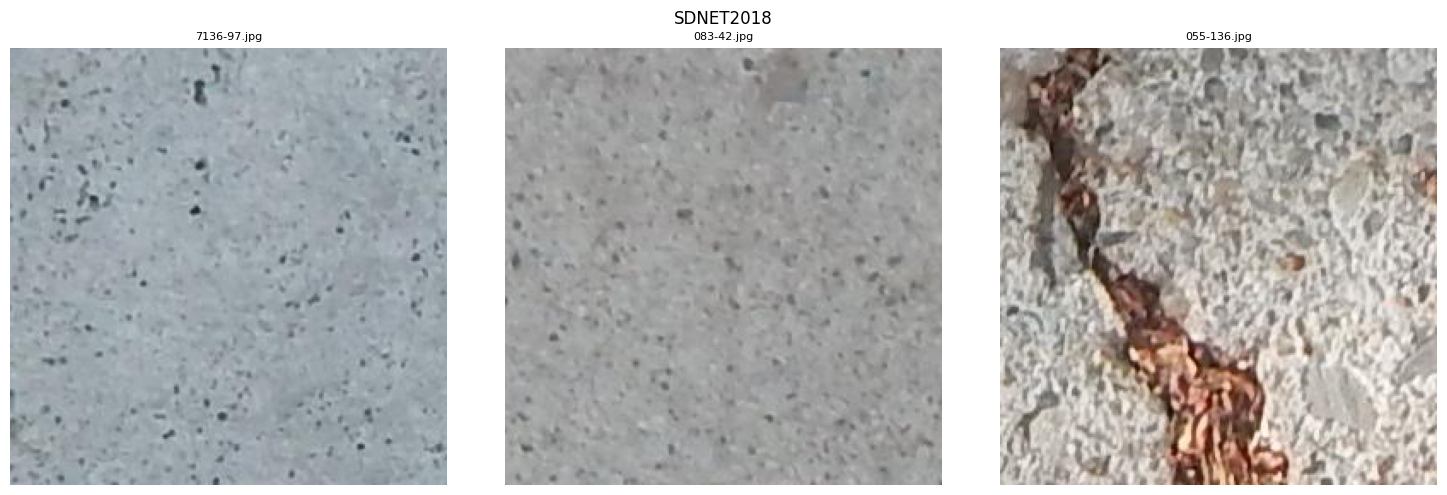

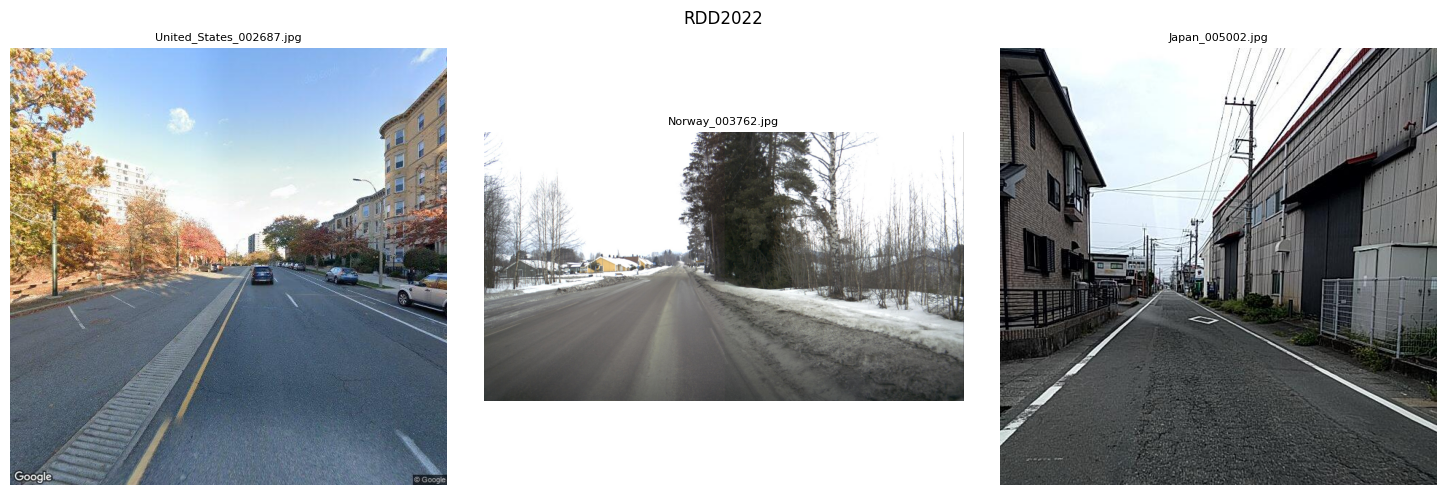

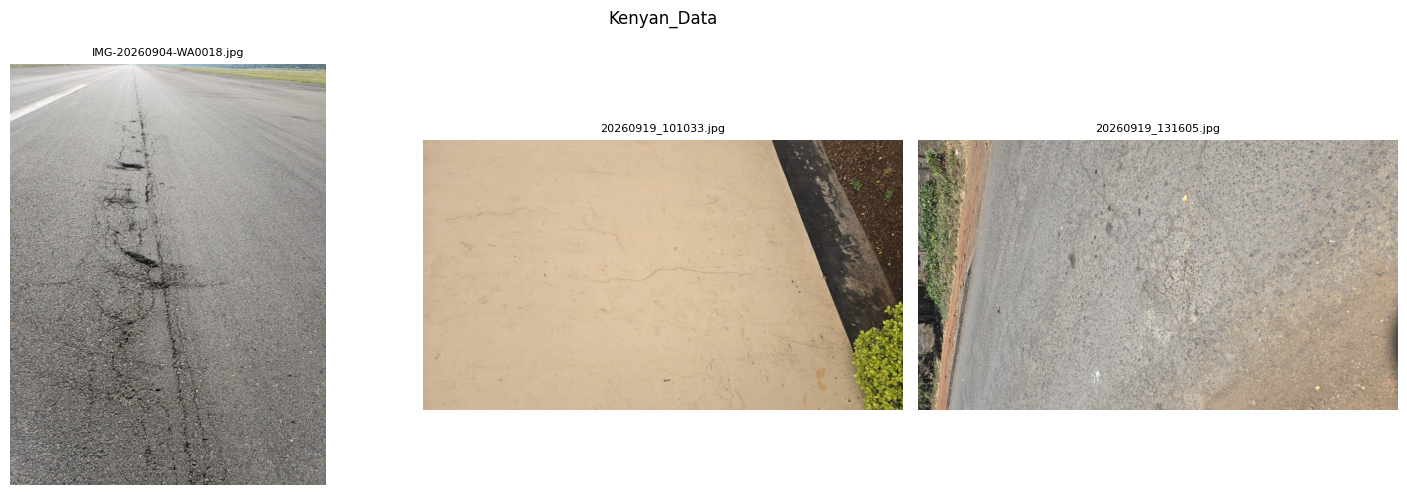

In [7]:
def random_image_paths(directory, n=4, seed=42):
    paths = files_with_extensions(directory, IMAGE_EXTENSIONS)
    rng = random.Random(seed)
    return rng.sample(paths, min(n, len(paths)))

for name, path in datasets.items():
    samples = random_image_paths(path, n=3, seed=42)

    if not samples:
        continue

    fig, axes = plt.subplots(1, len(samples), figsize=(15, 5))
    if len(samples) == 1:
        axes = [axes]

    for ax, img_path in zip(axes, samples):
        try:
            with Image.open(img_path) as img:
                ax.imshow(img.convert("RGB"))
            ax.set_title(img_path.name, fontsize=8)
            ax.axis("off")
        except Exception as exc:
            ax.set_title(f"Unreadable\n{exc}")
            ax.axis("off")

    fig.suptitle(name)
    plt.tight_layout()
    plt.show()

## 5. RDD2022 YOLO Annotation Inspection

Notebook 01 established that the current RDD2022 copy contains YOLO .txt files and no XML files.

This section inspects the actual class IDs and annotation syntax. Do not finalize the class mapping until the output below has been checked.

In [8]:
# ---------------------------------------------------------
# RDD2022 YOLO Annotation Inspection
# Sampled inspection only
# ---------------------------------------------------------

RDD_TXT_FILES = files_with_extensions(
    RDD_DIR,
    {".txt"}
)

print("Total RDD YOLO files:", len(RDD_TXT_FILES))


# Inspect only a small reproducible sample
SAMPLE_SIZE = 500
SEED = 42

rng = random.Random(SEED)

if len(RDD_TXT_FILES) > SAMPLE_SIZE:
    sampled_txt_files = rng.sample(
        RDD_TXT_FILES,
        SAMPLE_SIZE
    )
else:
    sampled_txt_files = RDD_TXT_FILES


class_id_counts = Counter()
invalid_line_examples = []

files_with_classes = 0


for txt_path in sampled_txt_files:

    try:
        with open(
            txt_path,
            "r",
            encoding="utf-8",
            errors="ignore"
        ) as f:

            lines = [
                line.strip()
                for line in f
                if line.strip()
            ]

        file_has_class = False

        for line in lines:

            parts = line.split()

            if len(parts) != 5:

                if len(invalid_line_examples) < 20:
                    invalid_line_examples.append(
                        (str(txt_path), line)
                    )

                continue

            try:
                class_id = int(parts[0])

                # Confirm YOLO numeric fields
                values = [
                    float(v)
                    for v in parts[1:]
                ]

                class_id_counts[class_id] += 1
                file_has_class = True

            except ValueError:

                if len(invalid_line_examples) < 20:
                    invalid_line_examples.append(
                        (str(txt_path), line)
                    )

        if file_has_class:
            files_with_classes += 1

    except Exception as exc:

        if len(invalid_line_examples) < 20:
            invalid_line_examples.append(
                (str(txt_path), str(exc))
            )


print("\nRDD2022 YOLO inspection")
print("------------------------")
print("Files sampled:", len(sampled_txt_files))
print("Files containing valid classes:", files_with_classes)

print("\nObserved RDD2022 class IDs:")
print(dict(sorted(class_id_counts.items())))


if invalid_line_examples:

    print("\nInvalid YOLO line examples:")

    for item in invalid_line_examples[:20]:
        print(item)

Total RDD YOLO files: 38386

RDD2022 YOLO inspection
------------------------
Files sampled: 500
Files containing valid classes: 350

Observed RDD2022 class IDs:
{0: 329, 1: 144, 2: 149, 3: 154, 4: 87}


In [9]:
# ---------------------------------------------------------
# Show actual sample YOLO annotation files
# ---------------------------------------------------------

def read_yolo_lines(txt_path):
    with open(
        txt_path,
        "r",
        encoding="utf-8",
        errors="ignore"
    ) as f:
        return [
            line.strip()
            for line in f
            if line.strip()
        ]


# Show a few sample annotation files
for txt_path in RDD_TXT_FILES[:5]:

    print("\nFILE:", txt_path)

    lines = read_yolo_lines(txt_path)

    if not lines:
        print("  [empty annotation file]")
        continue

    for line in lines[:10]:
        print(" ", line)


FILE: /content/drive/MyDrive/CS PROJECT II/Data/Raw Data/RDD2022/RDD_SPLIT/val/labels/Norway_006303.txt


NameError: name 'read_yolo_lines' is not defined

In [ ]:
# ---------------------------------------------------------
# Inspect RDD class IDs and annotation validity
# ---------------------------------------------------------

class_id_examples = {
    0: [],
    1: [],
    2: [],
    3: [],
    4: []
}

invalid_yolo_examples = []

for txt_path in sampled_txt_files:

    try:
        lines = read_yolo_lines(txt_path)

        for line in lines:

            parts = line.split()

            if len(parts) != 5:
                if len(invalid_yolo_examples) < 20:
                    invalid_yolo_examples.append(
                        (str(txt_path), line)
                    )
                continue

            try:
                class_id = int(parts[0])

                values = [
                    float(v)
                    for v in parts[1:]
                ]

                if class_id in class_id_examples:
                    if len(class_id_examples[class_id]) < 3:
                        class_id_examples[class_id].append(
                            (str(txt_path), line)
                        )

            except ValueError:

                if len(invalid_yolo_examples) < 20:
                    invalid_yolo_examples.append(
                        (str(txt_path), line)
                    )

    except Exception as exc:

        if len(invalid_yolo_examples) < 20:
            invalid_yolo_examples.append(
                (str(txt_path), str(exc))
            )


print("RDD2022 class ID examples")
print("=" * 60)

for class_id, examples in class_id_examples.items():

    print(f"\nClass ID {class_id}:")

    if not examples:
        print("  No examples found in sample.")
    else:
        for path, line in examples:
            print(" ", line)
            print("   ", path)


if invalid_yolo_examples:

    print("\nInvalid YOLO examples")
    print("=" * 60)

    for path, line in invalid_yolo_examples[:20]:
        print(path)
        print(line)

## RDD mapping checkpoint

For standard RDD four-class road-damage taxonomy, the expected mapping is:

*   D00 - Crack
*   D10 - Crack
*   D20 - Crack
*   D40 - Pothole

If the obsevered class IDs are not the expected four IDs, STOP before Notebook 03 and update the mapping from the actual annotation files.

Do not use D43 or D44 as RDD2022 classes unless your actual downloaded dataset demonstrably contains those classes. They are part of the four-class RDD2022 mappinf being used here





## 6. Basic Image-Annotation Pairing Check for RDD2022

In [ ]:
# ---------------------------------------------------------
# RDD2022 Image–Annotation Pairing Check
# ---------------------------------------------------------
#
# RDD structure:
#
# split/
# ├── images/
# │   └── image.jpg
# └── labels/
#     └── image.txt
#
# This check pairs files by split + filename stem.
# ---------------------------------------------------------

RDD_PATH = RDD_DIR

rdd_images = files_with_extensions(
    RDD_PATH,
    IMAGE_EXTENSIONS
)

rdd_labels = files_with_extensions(
    RDD_PATH,
    {".txt"}
)


def rdd_pair_key(path):
    """
    Creates a pairing key using:
        split directory + filename stem

    Example:
        val/images/Norway_006080.jpg
        val/labels/Norway_006080.txt

    Both become:
        val/Norway_006080
    """

    path = Path(path)

    split_dir = path.parent.parent

    relative_split = (
        split_dir
        .relative_to(RDD_PATH)
        .as_posix()
    )

    return f"{relative_split}/{path.stem}"


image_keys = {
    rdd_pair_key(path)
    for path in rdd_images
}

label_keys = {
    rdd_pair_key(path)
    for path in rdd_labels
}


paired_keys = image_keys & label_keys

missing_images = sorted(
    label_keys - image_keys
)

missing_labels = sorted(
    image_keys - label_keys
)


print("RDD2022 Image–Annotation Pairing")
print("=" * 60)

print("Images:", len(image_keys))
print("YOLO annotations:", len(label_keys))
print("Paired image/annotation files:", len(paired_keys))

print(
    "Annotations without matching image:",
    len(missing_images)
)

print(
    "Images without matching annotation:",
    len(missing_labels)
)


print(
    "\nExamples of annotations without images:"
)

for item in missing_images[:10]:
    print(" ", item)


print(
    "\nExamples of images without annotations:"
)

for item in missing_labels[:10]:
    print(" ", item)

In [ ]:
RDD_PATH = DATASET_PATHS["RDD2022"]

image_files = {
    p.relative_to(RDD_PATH).with_suffix("").as_posix()
    for p in RDD_PATH.rglob("*")
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
}

label_files = {
    p.relative_to(RDD_PATH).with_suffix("").as_posix()
    for p in RDD_PATH.rglob("*.txt")
}

missing_images = sorted(label_files - image_files)
missing_labels = sorted(image_files - label_files)

print("RDD2022 Image/Label Pairing")
print("-" * 50)

print("Images:", len(image_files))
print("YOLO labels:", len(label_files))
print("Labels without matching image:", len(missing_images))
print("Images without matching label:", len(missing_labels))

print("\nExamples of labels without images:")
for x in missing_images[:20]:
    print(" ", x)

print("\nExamples of images without labels:")
for x in missing_labels[:20]:
    print(" ", x)

## 7. RDD2022 Stratified Selection

In [ ]:
# ---------------------------------------------------------
# RDD2022 Selection Configuration
# ---------------------------------------------------------

from collections import defaultdict
import shutil
import math


RDD_SELECTED_DIR = SELECTED_DIR / "RDD2022"

RDD_SELECTED_IMAGES = (
    RDD_SELECTED_DIR / "images"
)

RDD_SELECTED_LABELS = (
    RDD_SELECTED_DIR / "labels"
)


RDD_SELECTED_IMAGES.mkdir(
    parents=True,
    exist_ok=True
)

RDD_SELECTED_LABELS.mkdir(
    parents=True,
    exist_ok=True
)


# ---------------------------------------------------------
# RDD class mapping
# ---------------------------------------------------------

RDD_CLASS_ID_TO_CODE = {
    0: "D00",
    1: "D10",
    2: "D20",
    3: "D40",
    4: "OTHER",
}


RDD_CODE_TO_TARGET = {
    "D00": "Crack",
    "D10": "Crack",
    "D20": "Crack",
    "D40": "Pothole",
}

In [ ]:
# ---------------------------------------------------------
# Find image corresponding to an RDD label
# ---------------------------------------------------------

def find_rdd_image(label_path):

    label_path = Path(label_path)

    stem = label_path.stem

    # Typical structure:
    #
    # split/
    # ├── images/
    # └── labels/

    split_dir = label_path.parent.parent

    images_dir = split_dir / "images"

    for ext in IMAGE_EXTENSIONS:

        candidate = (
            images_dir /
            f"{stem}{ext}"
        )

        if candidate.exists():
            return candidate

    # Fallback for unexpected structures

    for ext in IMAGE_EXTENSIONS:

        candidate = (
            label_path.parent /
            f"{stem}{ext}"
        )

        if candidate.exists():
            return candidate

    return None

In [ ]:
# ---------------------------------------------------------
# Extract country/source from RDD image filename
# ---------------------------------------------------------

def get_rdd_country(image_path):

    image_path = Path(image_path)

    stem = image_path.stem

    # Example:
    # Norway_006080.jpg
    #
    # Country becomes:
    # Norway

    if "_" in stem:

        return stem.split("_")[0]

    return image_path.parent.name

In [ ]:
# ---------------------------------------------------------
# Read RDD annotation classes for one image
# ---------------------------------------------------------

def get_rdd_codes(label_path):

    codes = set()

    try:

        with open(
            label_path,
            "r",
            encoding="utf-8",
            errors="ignore"
        ) as f:

            lines = f.readlines()


        for line in lines:

            parts = line.strip().split()

            if len(parts) != 5:
                continue


            try:

                class_id = int(parts[0])

            except ValueError:

                continue


            if class_id in RDD_CLASS_ID_TO_CODE:

                codes.add(
                    RDD_CLASS_ID_TO_CODE[class_id]
                )


    except Exception:

        pass


    return codes

In [ ]:
# ---------------------------------------------------------
# Build image-level RDD records
# ---------------------------------------------------------

rdd_records = []


for label_path in RDD_DIR.rglob("*.txt"):

    image_path = find_rdd_image(
        label_path
    )

    if image_path is None:
        continue


    codes = get_rdd_codes(
        label_path
    )

    if not codes:
        continue


    target_classes = {
        RDD_CODE_TO_TARGET[code]
        for code in codes
        if code in RDD_CODE_TO_TARGET
    }


    # Ignore files containing only
    # class 4 / OTHER.

    if not target_classes:
        continue


    country = get_rdd_country(
        image_path
    )


    rdd_records.append({

        "image_path": image_path,

        "label_path": label_path,

        "country": country,

        "codes": sorted(codes),

        "target_classes": sorted(
            target_classes
        )

    })


rdd_df = pd.DataFrame(
    rdd_records
)


print(
    "Usable RDD images:",
    len(rdd_df)
)


display(
    rdd_df[
        [
            "country",
            "codes",
            "target_classes"
        ]
    ]
    .value_counts()
    .reset_index(
        name="count"
    )
)

In [ ]:
# ---------------------------------------------------------
# Determine selection class
# ---------------------------------------------------------

def classify_rdd_record(row):

    classes = set(
        row["target_classes"]
    )


    if classes == {"Crack"}:

        return "Crack"


    if classes == {"Pothole"}:

        return "Pothole"


    return "Mixed"


rdd_df["selection_class"] = (
    rdd_df.apply(
        classify_rdd_record,
        axis=1
    )
)


print(
    "RDD selection pool:"
)

print(
    rdd_df[
        "selection_class"
    ].value_counts()
)

In [ ]:
# ---------------------------------------------------------
# Stratified sampling by country
# ---------------------------------------------------------

def stratified_sample(
    df,
    target_count,
    random_seed=42
):

    if len(df) < target_count:

        raise ValueError(
            f"Only {len(df)} images available, "
            f"but {target_count} requested."
        )


    country_counts = (
        df["country"]
        .value_counts()
    )


    raw_quotas = (
        country_counts /
        country_counts.sum()
    ) * target_count


    quotas = (
        raw_quotas
        .apply(math.floor)
        .astype(int)
    )


    remaining = (
        target_count -
        quotas.sum()
    )


    remainders = (
        raw_quotas - quotas
    ).sort_values(
        ascending=False
    )


    for country in remainders.index[
        :remaining
    ]:

        quotas[country] += 1


    selected_parts = []


    for country, quota in (
        quotas.items()
    ):

        if quota <= 0:
            continue


        country_df = df[
            df["country"] == country
        ]


        sampled = country_df.sample(
            n=int(quota),
            random_state=random_seed
        )


        selected_parts.append(
            sampled
        )


    return pd.concat(
        selected_parts,
        ignore_index=True
    )

In [ ]:
# ---------------------------------------------------------
# Inspect RDD source defect-code distribution
# ---------------------------------------------------------

print(
    "RDD source defect-code distribution:"
)


code_counts = Counter()


for _, row in selected_rdd.iterrows():

    for code in row["codes"]:

        code_counts[code] += 1


print(
    dict(
        sorted(
            code_counts.items()
        )
    )
)

In [ ]:
# ---------------------------------------------------------
# Validate RDD selection before copying
# ---------------------------------------------------------

assert len(selected_rdd) == 1200

assert (
    selected_rdd[
        "selection_class"
    ].value_counts()["Crack"]
    == 600
)

assert (
    selected_rdd[
        "selection_class"
    ].value_counts()["Pothole"]
    == 600
)


assert (
    selected_rdd[
        "codes"
    ]
    .apply(
        lambda codes:
        any(
            code in {
                "D00",
                "D10",
                "D20"
            }
            for code in codes
        )
    )
    .any()
)


print(
    "RDD selection validation passed."
)

print(
    "1200 images selected:"
)

print(
    "  Crack: 600"
)

print(
    "  Pothole: 600"
)

In [ ]:
# ---------------------------------------------------------
# Check for filename collisions
# ---------------------------------------------------------

image_name_counts = (
    selected_rdd["image_path"]
    .apply(lambda p: Path(p).name)
    .value_counts()
)

label_name_counts = (
    selected_rdd["label_path"]
    .apply(lambda p: Path(p).name)
    .value_counts()
)


duplicate_images = (
    image_name_counts[
        image_name_counts > 1
    ]
)

duplicate_labels = (
    label_name_counts[
        label_name_counts > 1
    ]
)


print(
    "Duplicate selected image filenames:",
    len(duplicate_images)
)

print(
    "Duplicate selected label filenames:",
    len(duplicate_labels)
)


if len(duplicate_images) > 0:

    print(
        "\nDuplicate image names:"
    )

    print(
        duplicate_images.head(20)
    )


if len(duplicate_labels) > 0:

    print(
        "\nDuplicate label names:"
    )

    print(
        duplicate_labels.head(20)
    )

In [ ]:
# ---------------------------------------------------------
# Copy selected RDD images and labels
# ---------------------------------------------------------

for _, row in selected_rdd.iterrows():

    image_path = Path(
        row["image_path"]
    )

    label_path = Path(
        row["label_path"]
    )


    destination_image = (
        RDD_SELECTED_IMAGES /
        image_path.name
    )

    destination_label = (
        RDD_SELECTED_LABELS /
        label_path.name
    )


    shutil.copy2(
        image_path,
        destination_image
    )


    shutil.copy2(
        label_path,
        destination_label
    )


print(
    "RDD2022 selection copied to:"
)

print(
    RDD_SELECTED_DIR
)

## 8. RDD2022 Selection Validation

In [ ]:
# ---------------------------------------------------------
# Validate copied RDD selection
# ---------------------------------------------------------

selected_images = files_with_extensions(
    RDD_SELECTED_IMAGES,
    IMAGE_EXTENSIONS
)

selected_labels = files_with_extensions(
    RDD_SELECTED_LABELS,
    {".txt"}
)


print(
    "Selected images:",
    len(selected_images)
)

print(
    "Selected labels:",
    len(selected_labels)
)


assert len(selected_images) == 1200

assert len(selected_labels) == 1200


print(
    "\nRDD2022 selected dataset validation passed."
)

## 9. Dataset Inspection Summary

In [ ]:
print("DATASET SUMMARY")
print("=" * 60)
display(overview_df)

print("\nNEXT STAGE")
print("Notebook 03 will validate annotations, apply the target class mapping,")
print("construct a normalized manifest, and create leakage-aware dataset splits.")